Reyhan Maulana Aryaduta 11220940000048

Muhammad Anthar Jailani Putra 11220940000029

# Import Library

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader, random_split
import numpy as np
import random
import os
import matplotlib.pyplot as plt
import copy
from torchvision import models


In [ ]:
# Set global seed for reproducibility
def set_seed(seed_value):
    """
    Mengatur seed untuk reproducibility di Python, NumPy, dan PyTorch.
    """
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False  # Menonaktifkan auto-tuner CuDNN
    os.environ['PYTHONHASHSEED'] = str(seed_value)

set_seed(42)  # Angka seed yang umum digunakan

# Tentukan penggunaan GPU jika tersedia, jika tidak, gunakan CPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {device}")

Menggunakan device: cuda:0


# Load Dataset

In [ ]:
# Data preprocessing and augmentation
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),  # Data augmentation: random flip
    transforms.RandomCrop(32, padding=4),  # Random crop with padding
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize as per notebook
])

transform_eval = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load CIFAR-10 dataset
train_data = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
eval_data = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_eval)
val_size = int(0.1 * len(train_data))
train_size = len(train_data) - val_size
train_indices, val_indices = random_split(range(len(train_data)), [train_size, val_size], generator=torch.Generator().manual_seed(42))
trainset = torch.utils.data.Subset(train_data, train_indices)
valset = torch.utils.data.Subset(eval_data, val_indices)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_eval)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:13<00:00, 12.5MB/s]


In [ ]:
from collections import Counter  # Impor Counter untuk menghitung frekuensi kelas

# Verifikasi distribusi kelas
train_labels = [train_data.targets[i] for i in train_indices]
val_labels = [eval_data.targets[i] for i in val_indices]
train_dist = Counter(train_labels)
val_dist = Counter(val_labels)

# Daftar nama kelas CIFAR-10
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Cetak distribusi kelas
print("Distribusi kelas di Train Set:")
for cls, count in sorted(train_dist.items()):
    print(f"Kelas {classes[cls]}: {count} gambar")
print("\nDistribusi kelas di Validation Set:")
for cls, count in sorted(val_dist.items()):
    print(f"Kelas {classes[cls]}: {count} gambar")

print(f"\nJumlah gambar di Train Set: {len(trainset)}")
print(f"Jumlah gambar di Validation Set: {len(valset)}")

Distribusi kelas di Train Set:
Kelas plane: 4512 gambar
Kelas car: 4488 gambar
Kelas bird: 4468 gambar
Kelas cat: 4529 gambar
Kelas deer: 4529 gambar
Kelas dog: 4486 gambar
Kelas frog: 4493 gambar
Kelas horse: 4500 gambar
Kelas ship: 4496 gambar
Kelas truck: 4499 gambar

Distribusi kelas di Validation Set:
Kelas plane: 488 gambar
Kelas car: 512 gambar
Kelas bird: 532 gambar
Kelas cat: 471 gambar
Kelas deer: 471 gambar
Kelas dog: 514 gambar
Kelas frog: 507 gambar
Kelas horse: 500 gambar
Kelas ship: 504 gambar
Kelas truck: 501 gambar

Jumlah gambar di Train Set: 45000
Jumlah gambar di Validation Set: 5000


# Model

In [ ]:
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


# Hyperparameter Tuning

In [ ]:
def train_and_evaluate(model, trainloader, valloader, testloader,
                       criterion, optimizer, epochs, patience, evaluate_test=False):

    scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    patience_counter = 0

    for epoch in range(epochs):
        # training
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for inputs, labels in valloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_loss / val_total
        val_acc = val_correct / val_total
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        # Print hasil training dan validation tiap epoch
        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%")

        # scheduler step
        scheduler.step(val_acc)

        # early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_model_wts)
    if evaluate_test:
        model.eval()
        test_preds, test_labels = [], []
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)
                test_preds.extend(predicted.cpu().numpy())
                test_labels.extend(labels.cpu().numpy())
        test_acc = 100 * sum(np.array(test_preds) == np.array(test_labels)) / len(test_labels)
        print(f'Test Accuracy: {test_acc:.2f}%')
        return train_losses, val_losses, train_accs, val_accs, test_preds, test_labels, best_val_acc

    return train_losses, val_losses, train_accs, val_accs, best_val_acc

In [ ]:
# Hyperparameter tuning with reduced epochs
learning_rates = [0.001, 0.003]
batch_sizes = [32, 64]
best_val_acc = 0
best_params = {}
best_model = None

for lr in learning_rates:
    for bs in batch_sizes:
        print(f'\n🔍 Tuning: lr={lr}, batch_size={bs}')

        trainloader = DataLoader(trainset, batch_size=bs, shuffle=True)
        valloader = DataLoader(valset, batch_size=bs, shuffle=False)
        testloader = DataLoader(testset, batch_size=bs, shuffle=False)

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)

        train_losses, val_losses, train_accs, val_accs, curr_best_val_acc = train_and_evaluate(
            model, trainloader, valloader, testloader,
            criterion, optimizer, epochs=10, patience=3, evaluate_test=False
        )

        if curr_best_val_acc > best_val_acc:
            best_val_acc = curr_best_val_acc
            best_params = {'lr': lr, 'batch_size': bs}
            best_model = copy.deepcopy(model)
            best_train_losses = train_losses
            best_val_losses = val_losses
            best_train_accs = train_accs
            best_val_accs = val_accs

print(f'\n✅ Best Hyperparameters: {best_params}, Validation Accuracy: {best_val_acc:.4f}')



🔍 Tuning: lr=0.001, batch_size=32
Epoch 1/10 | Train Loss: 1.6013, Train Acc: 42.02% | Val Loss: 1.4365, Val Acc: 48.22%
Epoch 2/10 | Train Loss: 1.2364, Train Acc: 56.26% | Val Loss: 1.1384, Val Acc: 60.86%
Epoch 3/10 | Train Loss: 1.0847, Train Acc: 62.13% | Val Loss: 1.0086, Val Acc: 65.08%
Epoch 4/10 | Train Loss: 0.9744, Train Acc: 65.99% | Val Loss: 0.8563, Val Acc: 69.50%
Epoch 5/10 | Train Loss: 0.8934, Train Acc: 68.97% | Val Loss: 0.7875, Val Acc: 71.92%
Epoch 6/10 | Train Loss: 0.8309, Train Acc: 71.46% | Val Loss: 0.7766, Val Acc: 72.10%
Epoch 7/10 | Train Loss: 0.7834, Train Acc: 73.03% | Val Loss: 0.6889, Val Acc: 75.92%
Epoch 8/10 | Train Loss: 0.7408, Train Acc: 74.68% | Val Loss: 0.6577, Val Acc: 77.36%
Epoch 9/10 | Train Loss: 0.6979, Train Acc: 75.94% | Val Loss: 0.7328, Val Acc: 74.34%
Epoch 10/10 | Train Loss: 0.6645, Train Acc: 77.25% | Val Loss: 0.6565, Val Acc: 77.02%

🔍 Tuning: lr=0.001, batch_size=64
Epoch 1/10 | Train Loss: 0.6447, Train Acc: 77.73% | Val Lo

In [ ]:
torch.save(best_model.state_dict(), "model_ResNet18_new.pth")
print("Best ResNet18 model saved as 'model_ResNet18_new.pth'")

Best ResNet18 model saved as 'model_ResNet18_new.pth'


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

# # Simpan model ke folder di Google Drive
# torch.save(best_model.state_dict(), '/content/drive/MyDrive/Colab Notebooks/Model/model_ResNet18_new.pth')
# print("Best CNN model saved to Google Drive as 'model_ResNet18_new.pth'")

In [ ]:
# Evaluate the best model on the test set
print('\nEvaluating best model on test set:')
trainloader = DataLoader(trainset, batch_size=best_params['batch_size'], shuffle=True)
valloader = DataLoader(valset, batch_size=best_params['batch_size'], shuffle=False)
testloader = DataLoader(testset, batch_size=best_params['batch_size'], shuffle=False)
train_losses, val_losses, train_accs, val_accs, test_preds, test_labels, best_val_acc = train_and_evaluate(
    best_model, trainloader, valloader, testloader, criterion, optimizer,
    epochs=1, patience=15, evaluate_test=True)


Evaluating best model on test set:
Epoch 1/1 | Train Loss: 0.3713, Train Acc: 87.09% | Val Loss: 0.4814, Val Acc: 83.84%
Test Accuracy: 82.79%


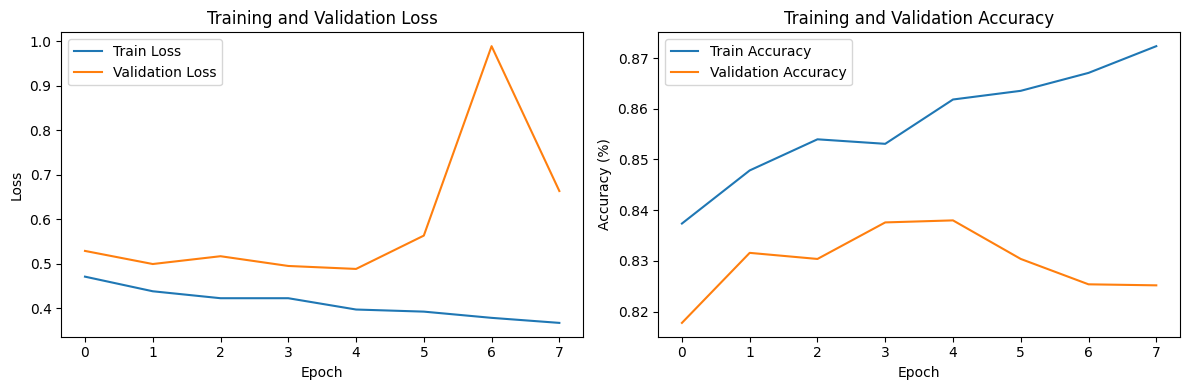

In [ ]:
# Training and Validation Loss & Accuracy Plots
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(best_train_losses, label='Train Loss')
plt.plot(best_val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(best_train_accs, label='Train Accuracy')
plt.plot(best_val_accs, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.savefig('training_validation_plots.png')
plt.show()

In [ ]:
# Tampilkan Akurasi dari Hasil Pelatihan
final_train_acc = best_train_accs[-1] if best_train_accs else 0
final_val_acc = best_val_acc
print('\nFinal Accuracies:')
print(f'Training Accuracy: {final_train_acc:.2f}%')
print(f'Validation Accuracy: {final_val_acc:.2f}%')
print(f'Test Accuracy: {100 * sum(np.array(test_preds) == np.array(test_labels)) / len(test_labels):.2f}%')


Final Accuracies:
Training Accuracy: 0.87%
Validation Accuracy: 0.84%
Test Accuracy: 82.79%


# Evaluasi

In [ ]:
# !pip install gdown
# import gdown

# # ID file Google Drive
# file_id = "1LT_UeI4MtLPwkY4WiZAmm6tqFnZUgYg9"
# output_path = "model_ResNet18_new.pth"

# # Download file
# gdown.download(f"https://drive.google.com/uc?id={file_id}", output_path, quiet=False)

## Evaluation Metric

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

In [ ]:
def test(model, loader, device='cpu'):
    model.eval()
    preds = []
    targets = []
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1)
            preds.extend(pred.cpu().numpy())
            targets.extend(target.cpu().numpy())
    return np.array(preds), np.array(targets)

In [ ]:
resnet_preds, resnet_targets = test(model, testloader, 'cuda:0')

In [ ]:
# Tentukan perangkat
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Impor ResNet18
model = models.resnet18(pretrained=False)

# Ganti lapisan akhir (fc) untuk sesuai dengan jumlah kelas (10 kelas)
model.fc = nn.Linear(model.fc.in_features, 10)

# Pindahkan model ke perangkat
model = model.to(device)

# Muat bobot dari file
weights = torch.load("model_ResNet18_new.pth", map_location=device)

# Muat bobot ke model
model.load_state_dict(weights)

print("ResNet18 model loaded successfully with saved weights.")

ResNet18 model loaded successfully with saved weights.


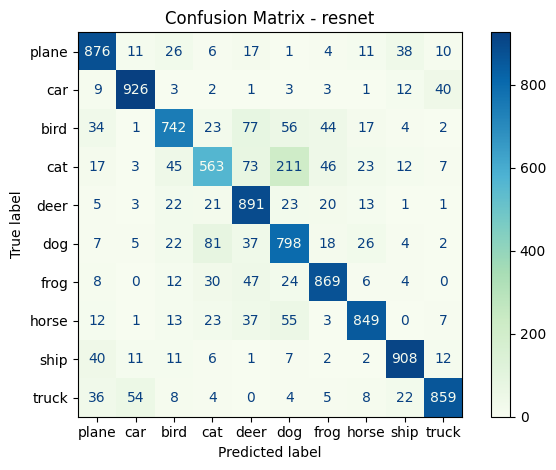

In [ ]:
cm_resnet = confusion_matrix(resnet_targets, resnet_preds)
disp_resnet = ConfusionMatrixDisplay(confusion_matrix=cm_resnet, display_labels=classes)

disp_resnet.plot(cmap='GnBu')
plt.title("Confusion Matrix - resnet")
plt.tight_layout()
plt.show()

In [ ]:
def compute_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision (macro)': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall (macro)': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1 Score (macro)': f1_score(y_true, y_pred, average='macro', zero_division=0)
    }

In [ ]:
resnet_metrics = compute_metrics(resnet_targets, resnet_preds)

metrics_df = pd.DataFrame([resnet_metrics], index= ['resnet'])
metrics_df

,Accuracy,Precision (macro),Recall (macro),F1 Score (macro)
resnet,0.8281,0.830592,0.8281,0.826665


## Feature Maps

In [ ]:
dataiter = iter(trainloader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

In [ ]:
def get_feature_maps(model, x):
    # Daftar untuk menyimpan feature maps
    features = []

    # Hook untuk menangkap output dari lapisan tertentu
    def hook(module, input, output):
        features.append(output)

    # Daftarkan hook pada lapisan yang diinginkan (misalnya, layer1 atau layer2)
    # Anda bisa menyesuaikan lapisan berdasarkan kebutuhan
    model.layer1.register_forward_hook(hook)
    model.layer2.register_forward_hook(hook)

    # Forward pass
    with torch.no_grad():
        output = model(x)

    # Ambil feature maps dari hook
    fmap1 = features[0]  # Feature map dari layer1
    fmap2 = features[1]  # Feature map dari layer2

    return output, fmap1, fmap2

# Forward pass dengan mengekstrak feature maps
with torch.no_grad():  # Menonaktifkan perhitungan gradien
    outputs, fmap1, fmap2 = get_feature_maps(model, images)  # Forward pass
    preds = outputs.argmax(dim=1)  # Ambil prediksi kelas

print("ResNet18 predictions and feature maps generated successfully.")

ResNet18 predictions and feature maps generated successfully.


In [ ]:
correct_indices = (preds == labels).nonzero(as_tuple=True)[0]
# Membandingkan prediksi dengan label sebenarnya → menghasilkan tensor boolean
# .nonzero(as_tuple=True) menghasilkan indeks dari prediksi yang benar
# [0] digunakan untuk mengambil tensor indeksnya saja (bukan tuple)

wrong_indices = (preds != labels).nonzero(as_tuple=True)[0]
# Sama seperti sebelumnya, tapi untuk prediksi yang salah

correct_idx = correct_indices[0].item() if correct_indices.numel() > 0 else 0
# Mengambil indeks pertama dari prediksi yang benar
# Jika tidak ada prediksi benar, fallback ke indeks 0 (agar tidak error)

wrong_idx = wrong_indices[0].item() if wrong_indices.numel() > 0 else correct_idx
# Mengambil indeks pertama dari prediksi yang salah
# Jika tidak ada prediksi salah, fallback ke indeks yang benar (agar tetap punya satu sampel)


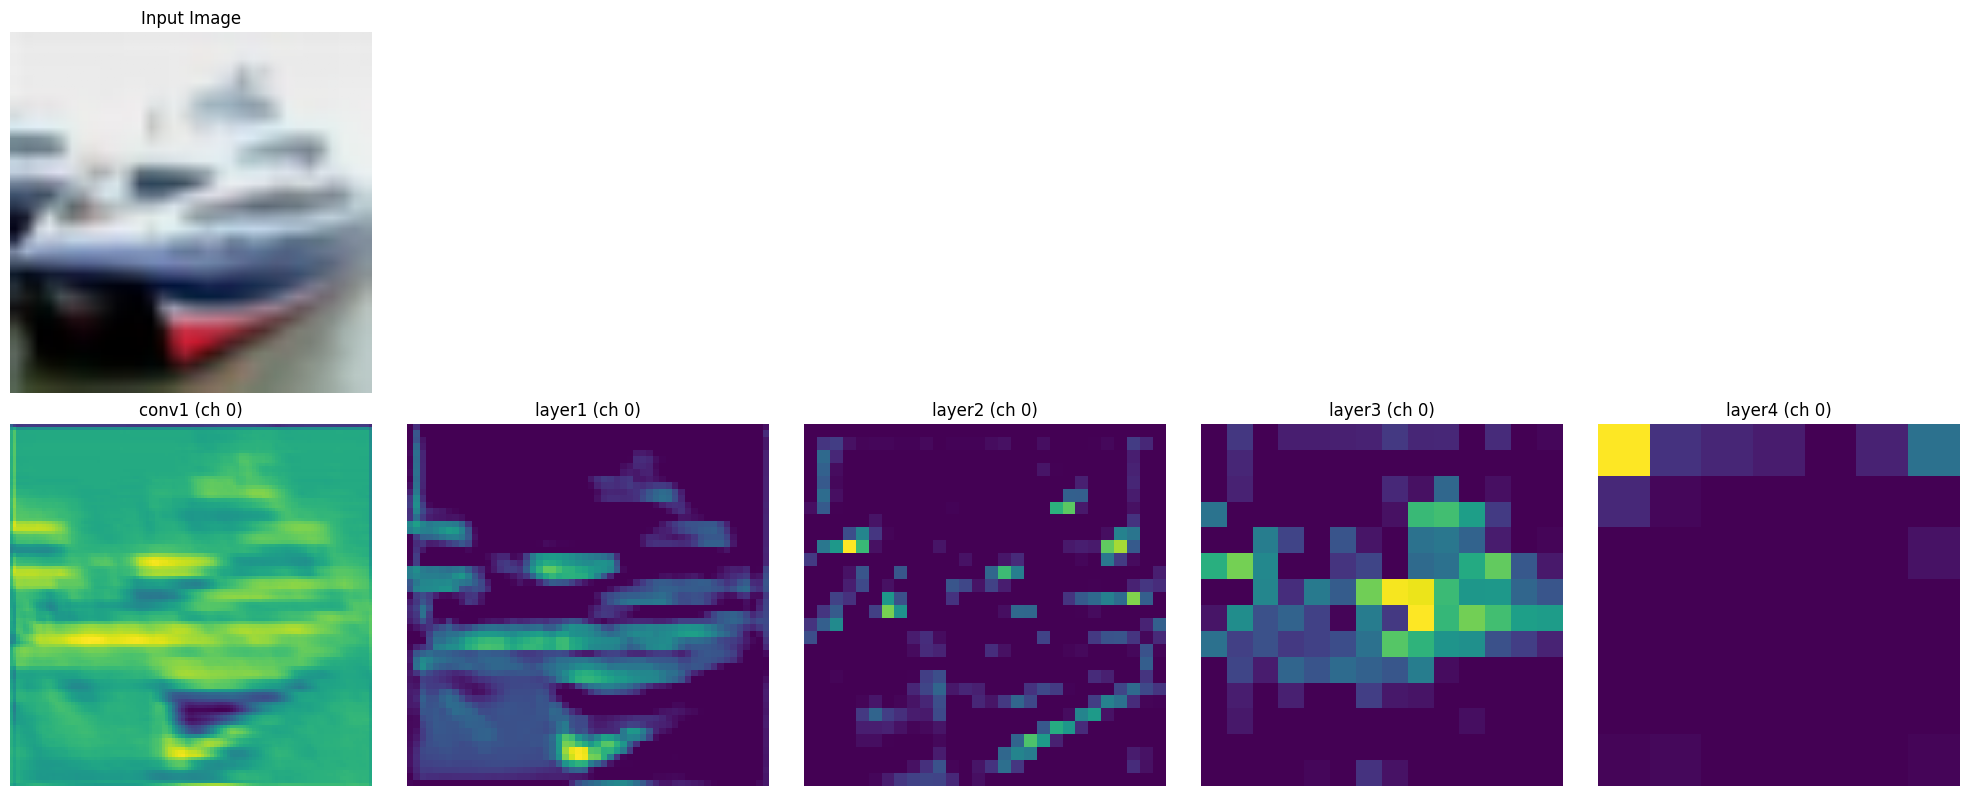

In [ ]:
import torch
import torchvision
from torchvision import transforms, datasets, models
import matplotlib.pyplot as plt

# Tentukan perangkat
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Definisikan transformasi untuk dataset CIFAR-10
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Ubah ukuran gambar ke 224x224 (dibutuhkan ResNet)
    transforms.ToTensor(),  # Ubah gambar ke tensor
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalisasi untuk CIFAR-10
])

# Load dataset CIFAR-10 dengan transformasi yang benar
dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Ambil satu gambar
image, label = dataset[1]  # Ambil gambar kedua (indeks 1)
img = image.unsqueeze(0).to(device)  # [1, 3, 224, 224]

# --- Hook untuk menangkap feature maps ---
feature_maps = {}

def get_activation(name):
    def hook(model, input, output):
        feature_maps[name] = output.detach().cpu()
    return hook

# Layer yang di-hook
hooks = []
layers_to_hook = {
    'conv1': model.conv1,
    'layer1': model.layer1[0],
    'layer2': model.layer2[0],
    'layer3': model.layer3[0],
    'layer4': model.layer4[0],
}
for name, layer in layers_to_hook.items():
    hooks.append(layer.register_forward_hook(get_activation(name)))

# Forward pass
with torch.no_grad():
    _ = model(img)

# Lepas semua hook
for hook in hooks:
    hook.remove()

# --- Visualisasi ---
def show_input_and_feature_maps(input_img, feature_maps_dict, num_channels=4):
    num_layers = len(feature_maps_dict)
    fig, axes = plt.subplots(2, num_layers, figsize=(4*num_layers, 8))

    # Tampilkan gambar input di baris atas
    input_img = input_img.permute(1, 2, 0).cpu()  # [3, H, W] -> [H, W, 3]
    input_img = (input_img * 0.5) + 0.5  # Undo normalization
    axes[0, 0].imshow(input_img)
    axes[0, 0].set_title("Input Image")
    axes[0, 0].axis('off')

    # Kosongkan sisa baris atas jika tidak pakai semua kolom
    for i in range(1, num_layers):
        axes[0, i].axis('off')

    # Tampilkan feature maps di baris bawah
    for idx, (layer_name, fmap) in enumerate(feature_maps_dict.items()):
        fmap = fmap[0]  # [C, H, W]
        axes[1, idx].imshow(fmap[0].numpy(), cmap='viridis')  # channel ke-0
        axes[1, idx].set_title(f"{layer_name} (ch 0)")
        axes[1, idx].axis('off')

    plt.tight_layout()
    plt.show()

# Panggil fungsi visualisasi
show_input_and_feature_maps(image, feature_maps)

In [ ]:
print("Wrong Predictions and Visualizations:")
for idx, y in enumerate(wrong_indices):
    true_label = labels[y].item()
    pred_label = preds[y].item()

    print(f"{idx+1}. Wrong: Index = {y.item()} - Pred: {classes[pred_label]}, True: {classes[true_label]}")


print(f"\nTotal wrong predictions: {len(wrong_indices)}")


Wrong Predictions and Visualizations:
1. Wrong: Index = 17 - Pred: deer, True: cat
2. Wrong: Index = 39 - Pred: dog, True: cat
3. Wrong: Index = 46 - Pred: car, True: truck
4. Wrong: Index = 60 - Pred: dog, True: cat
5. Wrong: Index = 61 - Pred: truck, True: plane

Total wrong predictions: 5


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


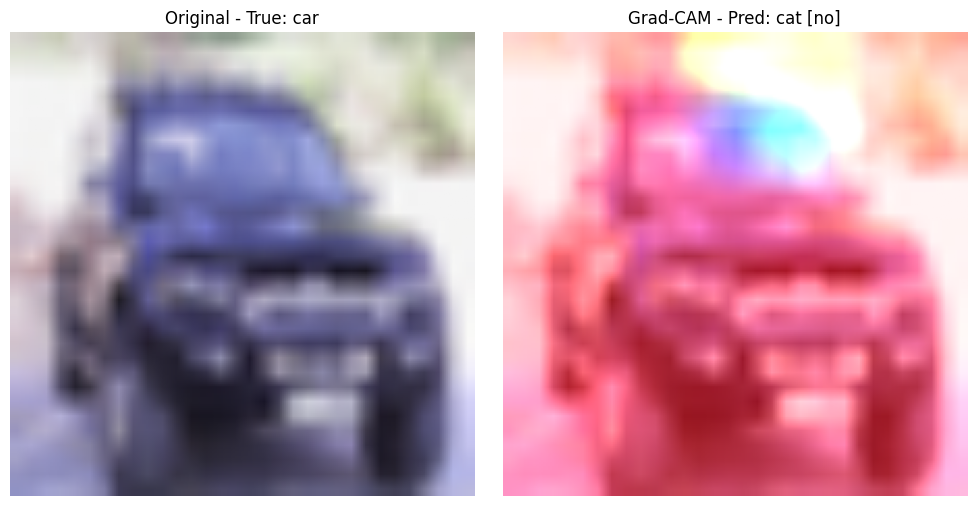

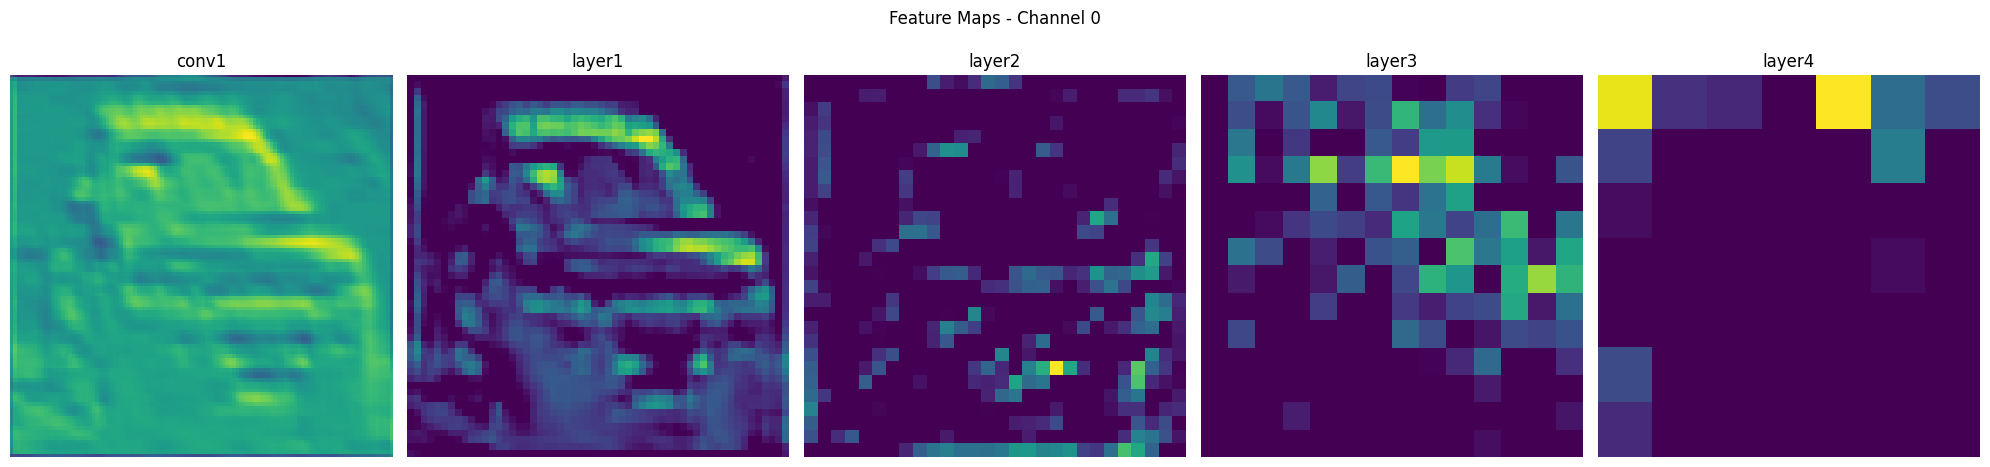

In [ ]:
import torch
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2
from torchvision import datasets # Import datasets here


# CIFAR-10 label names
class_names = ['plane', 'car', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Load one sample image from CIFAR-10 or custom
# Ganti ini sesuai input kamu:

# Using an image from the test dataset
transform_eval = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])
dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_eval)
image, label = dataset[9] # Mengambil gambar ke-8 dari testset

img = image.unsqueeze(0).to(device)  # shape [1, C, H, W]

# --- 2. Grad-CAM Preparation ---
# Note: target_layer should be a convolutional layer before the final pooling/flattening.
# For ResNet18, a good choice is the last convolutional layer before the average pool.
# model.layer4[1] is the second BasicBlock in layer4. .conv2 is its second conv layer.
target_layer = model.layer4[1].conv2

gradients = []
activations = []

def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0].detach())

def forward_hook(module, input, output):
    activations.append(output.detach())

# Register hooks
forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_backward_hook(backward_hook)

# Forward pass
output = model(img)
# Ensure output is for 10 classes as modified
pred_class = output.argmax(dim=1).item()
is_correct = pred_class == label

# Backward pass
model.zero_grad()
# The score should be from the output of the 10-class layer
class_score = output[0, pred_class]
class_score.backward()

# Grad-CAM Calculation
grad = gradients[0]
act = activations[0]
weights = grad.mean(dim=(2, 3), keepdim=True)  # GAP over H,W
cam = (weights * act).sum(dim=1).squeeze()  # [H, W]
cam = F.relu(cam)
# Normalize CAM to be between 0 and 1 for visualization
cam -= cam.min()
cam /= cam.max()

cam = cam.cpu().numpy()
img_np = image.permute(1, 2, 0).cpu().numpy()
# Undo normalization for display
img_np = (img_np * 0.5) + 0.5
img_np = np.clip(img_np, 0, 1) # Ensure values are within valid range for display

# --- 3. Show Grad-CAM & Prediction ---
# Now pred_class will be between 0 and 9, fitting the class_names list
true_label_name = class_names[label]
pred_label_name = class_names[pred_class]

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img_np)
ax[0].set_title(f"Original - True: {true_label_name}")
ax[0].axis('off')

# Overlay Grad-CAM heatmap (optional but common)
# You might need to install opencv: !pip install opencv-python
heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
heatmap = np.float32(heatmap) / 255
# Resize heatmap to image size (224, 224) if not already
heatmap = cv2.resize(heatmap, (img_np.shape[1], img_np.shape[0]))
# Combine heatmap and original image
cam_img = heatmap + img_np
cam_img = np.clip(cam_img, 0, 1)

ax[1].imshow(cam_img) # Show overlaid image instead of just heatmap
ax[1].set_title(f"Grad-CAM - Pred: {pred_label_name} {'[yes]' if is_correct else '[no]'}")
ax[1].axis('off')
plt.tight_layout()
plt.show()

# Remove hooks
forward_handle.remove()
backward_handle.remove()

# --- 4. Feature Map Analysis Per Layer ---
feature_maps = {}

def get_activation(name):
    def hook(model, input, output):
        feature_maps[name] = output.detach().cpu()
    return hook

# Using the modified model with 10 output classes
layers_to_hook = {
    'conv1': model.conv1,
    'layer1': model.layer1[0], # First block of layer1
    'layer2': model.layer2[0], # First block of layer2
    'layer3': model.layer3[0], # First block of layer3
    'layer4': model.layer4[0], # First block of layer4
}

hooks = []
for name, layer in layers_to_hook.items():
    hooks.append(layer.register_forward_hook(get_activation(name)))

with torch.no_grad():
    # No need to capture output here if only hooking
    _ = model(img)

for h in hooks:
    h.remove()

# --- 5. Plot Feature Maps (channel 0 only) side-by-side ---
fig, axs = plt.subplots(1, len(layers_to_hook), figsize=(20, 5))
for i, (name, fmap) in enumerate(feature_maps.items()):
    # fmap shape is [1, channels, H, W], take batch 0 and channel 0
    axs[i].imshow(fmap[0, 0], cmap='viridis')
    axs[i].set_title(name)
    axs[i].axis('off')
plt.suptitle("Feature Maps - Channel 0")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 195MB/s]
<ipython-input-42-2dc16e98600d>:103: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython

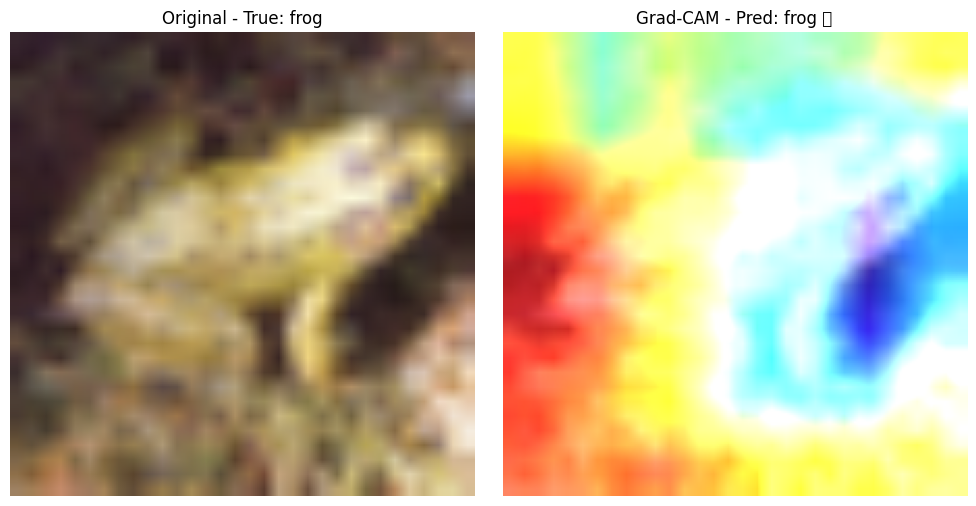

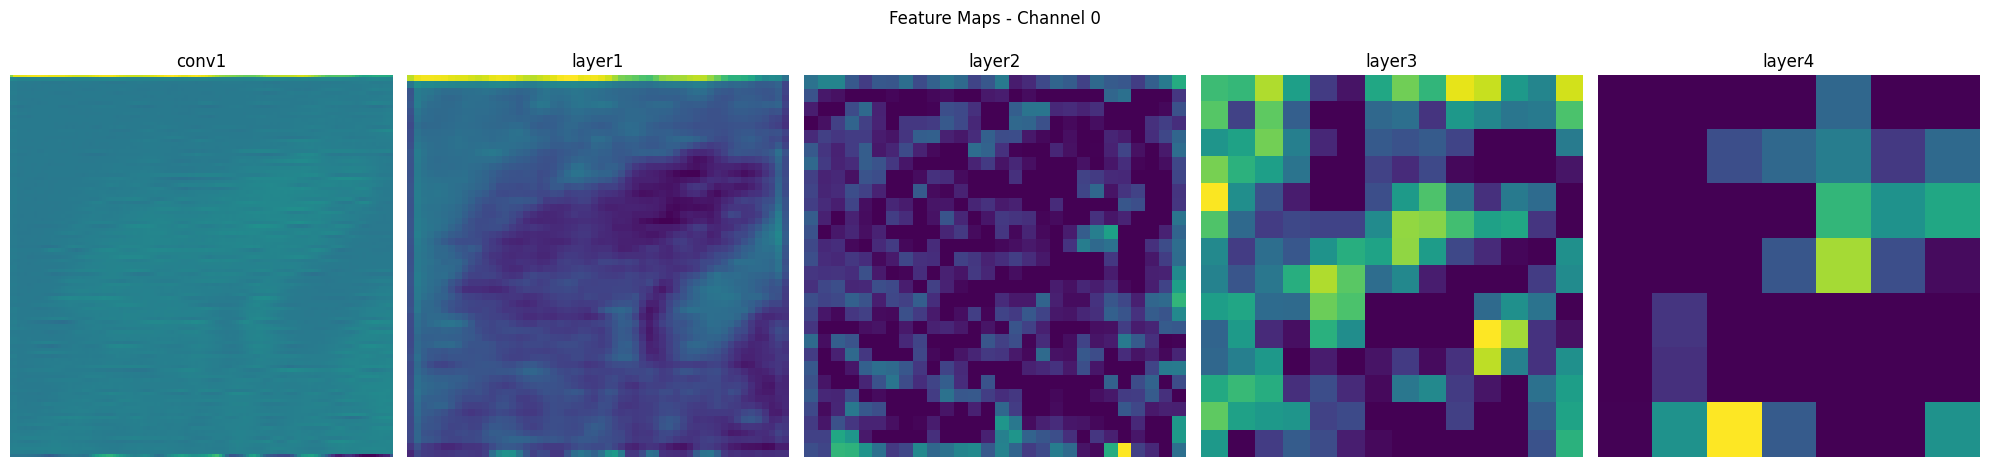

In [ ]:
import torch
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision import datasets
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2

# --- 1. Setup Model & Dataset ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)
model.fc = torch.nn.Linear(model.fc.in_features, 10)  # Adjust for CIFAR-10
model = model.to(device)
model.eval()

class_names = ['plane', 'car', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

transform_eval = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_eval)

correct_samples = []
wrong_samples = []

for idx in range(len(dataset)):
    image, label = dataset[idx]
    img = image.unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(img)
    pred_class = output.argmax(dim=1).item()

    if pred_class == label and len(correct_samples) < 3:
        correct_samples.append((img, image, label, pred_class))
    elif pred_class != label and len(wrong_samples) < 3:
        wrong_samples.append((img, image, label, pred_class))

    if len(correct_samples) == 3 and len(wrong_samples) == 3:
        break


# --- 3. Grad-CAM Hooks ---
target_layer = model.layer4[1].conv2
gradients = []
activations = []

def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0].detach())

def forward_hook(module, input, output):
    activations.append(output.detach())

forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_backward_hook(backward_hook)

# Forward & Backward
output = model(img)
class_score = output[0, pred_class]
model.zero_grad()
class_score.backward()

# Grad-CAM Calculation
grad = gradients[0]
act = activations[0]
weights = grad.mean(dim=(2, 3), keepdim=True)
cam = (weights * act).sum(dim=1).squeeze()
cam = F.relu(cam)
cam -= cam.min()
cam /= cam.max()
cam = cam.cpu().numpy()

# Undo normalization
img_np = image.permute(1, 2, 0).cpu().numpy()
img_np = (img_np * 0.5) + 0.5
img_np = np.clip(img_np, 0, 1)

# Heatmap overlay
heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
heatmap = np.float32(heatmap) / 255
heatmap = cv2.resize(heatmap, (img_np.shape[1], img_np.shape[0]))
cam_img = heatmap + img_np
cam_img = np.clip(cam_img, 0, 1)

# --- 4. Visualization ---
true_label_name = class_names[label]
pred_label_name = class_names[pred_class]

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img_np)
ax[0].set_title(f"Original - True: {true_label_name}")
ax[0].axis('off')

ax[1].imshow(cam_img)
ax[1].set_title(f"Grad-CAM - Pred: {pred_label_name} ✅")
ax[1].axis('off')
plt.tight_layout()
plt.show()

forward_handle.remove()
backward_handle.remove()

# --- 5. Feature Map Analysis ---
feature_maps = {}
def get_activation(name):
    def hook(model, input, output):
        feature_maps[name] = output.detach().cpu()
    return hook

layers_to_hook = {
    'conv1': model.conv1,
    'layer1': model.layer1[0],
    'layer2': model.layer2[0],
    'layer3': model.layer3[0],
    'layer4': model.layer4[0],
}

hooks = []
for name, layer in layers_to_hook.items():
    hooks.append(layer.register_forward_hook(get_activation(name)))

with torch.no_grad():
    _ = model(img)

for h in hooks:
    h.remove()

fig, axs = plt.subplots(1, len(layers_to_hook), figsize=(20, 5))
for i, (name, fmap) in enumerate(feature_maps.items()):
    axs[i].imshow(fmap[0, 0], cmap='viridis')
    axs[i].set_title(name)
    axs[i].axis('off')
plt.suptitle("Feature Maps - Channel 0")
plt.tight_layout()
plt.show()
